# Graph Dissimilarity Tutorial

This tutorial walks through how to compare two graph embeddings stored in an `AnnData` object.
This is useful for assessing how differently two single-cell integration methods organize cells in their respective neighborhood graphs.

In [1]:
import scanpy as sc
import anndata as ad
import scatlastb_utils as atl

sc.set_figure_params(frameon=False)

/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Step 1: Prepare data

In [2]:
adatas = {
    "pbmc3k": sc.datasets.pbmc3k_processed(),
    "pbmc68k": sc.datasets.pbmc68k_reduced(),
}

In [3]:
# load example PBMC datasets
adata = ad.concat(adatas, label='batch', join='inner')
del adata.obsm
adata

AnnData object with n_obs × n_vars = 3338 × 208
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain', 'batch'

In [4]:
# regular scanpy workflow
pca_key = "PCA"
sc.pp.pca(adata, key_added=pca_key)
sc.pp.neighbors(adata, use_rep=pca_key, key_added=pca_key, n_neighbors=50)
sc.tl.umap(adata, neighbors_key=pca_key, key_added=f"{pca_key}_umap")
adata

AnnData object with n_obs × n_vars = 3338 × 208
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain', 'batch'
    uns: 'PCA', 'PCA_umap'
    obsm: 'PCA', 'PCA_umap'
    varm: 'PCA'
    obsp: 'PCA_distances', 'PCA_connectivities'

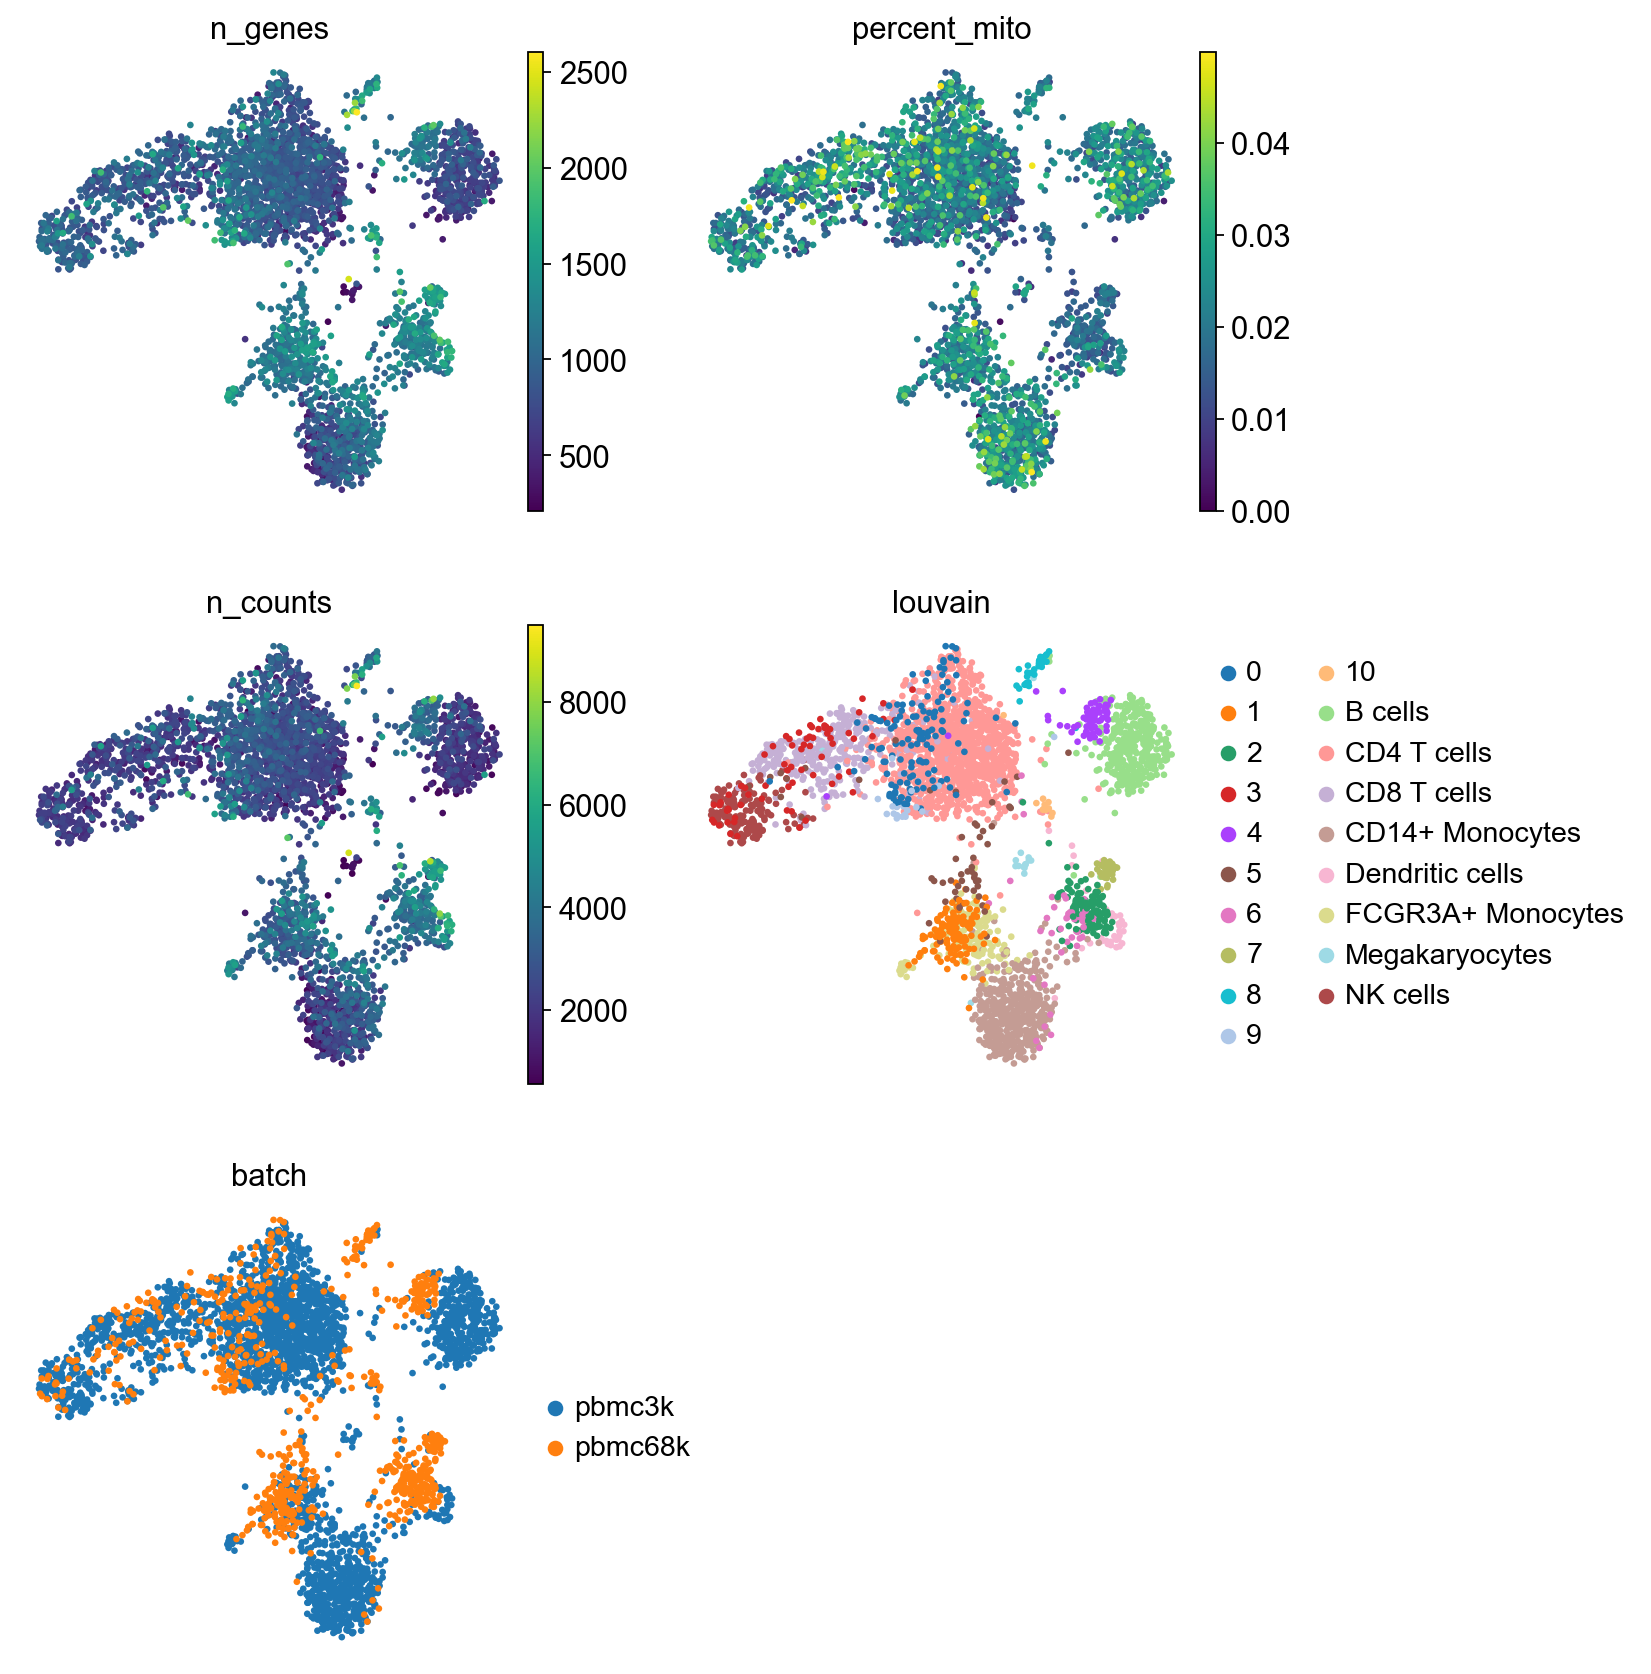

In [5]:
sc.pl.embedding(adata, basis=f"{pca_key}_umap", color=adata.obs.columns, ncols=2)

In [6]:
# provide an integrated embedding with combat
combat_key = "combat"
adata.obsm[combat_key] = sc.pp.combat(adata, key="batch", inplace=False)
sc.pp.neighbors(adata, use_rep=combat_key, key_added=combat_key, n_neighbors=50)
sc.tl.umap(adata, neighbors_key=combat_key, key_added=f"{combat_key}_umap")

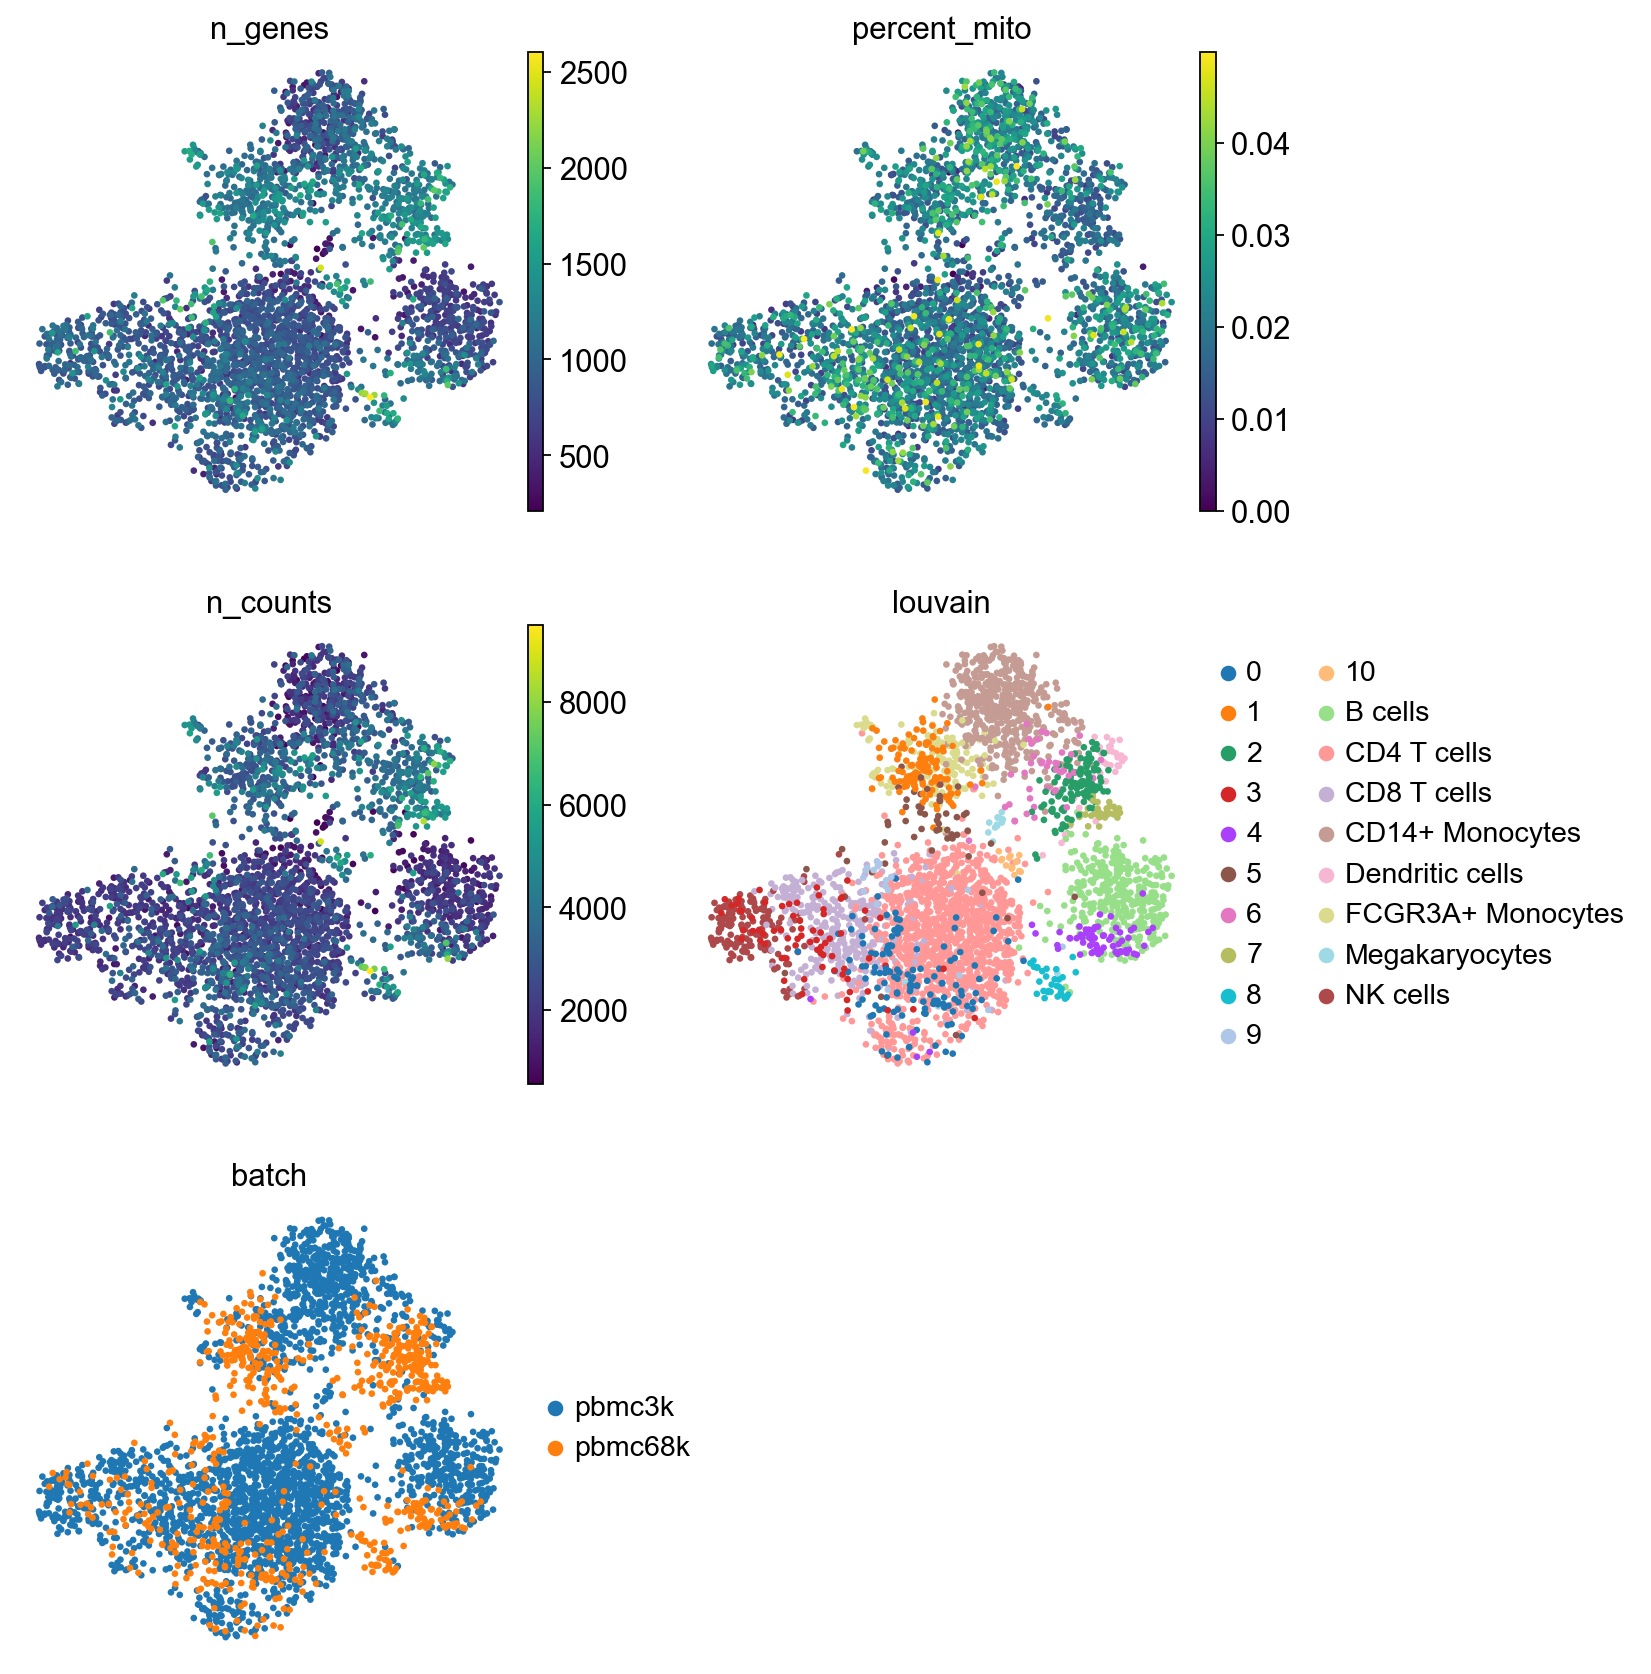

In [7]:
sc.pl.embedding(adata, basis=f"{combat_key}_umap", color=adata.obs.columns, ncols=2)

## Step 2: Run pairwise comparison of distances

`compare_distances` computes several per-cell metrics characterizing how similar the neighborhoods are between two embeddings. You run it **twice** — once in each direction — because the neighborhoods used as the reference differ depending on which integration is "primary".

In [8]:
diff_metrics = [
    "avg_distance_1",
    "avg_distance_2",
    "avg_difference",
    "avg_distance_diff",
    "spearman_correlation",
]

In [9]:
comp1 = f"{pca_key}-vs-{combat_key}"
adata.obs[[f"{metric}:{comp1}" for metric in diff_metrics]] = atl.metrics.compare_distances(
    adata,
    obsp_connectivities_1=f"{pca_key}_connectivities",
    obsp_distances_1=f"{pca_key}_distances",
    obsm_key_1=pca_key,
    obsp_connectivities_2=f"{combat_key}_connectivities",
    obsp_distances_2=f"{combat_key}_distances",
    obsm_key_2=combat_key,
    scale_distances=True,
)

70193 edges to recompute


Computing distances: 100%|██████████| 3236/3236 [00:00<00:00, 71435.62it/s]


scale distances by 0.9 quantile...
Calculate differences...


Spearman correlation: 100%|██████████| 1/1 [00:01<00:00,  1.18s/batch]


Then swap the order to get the reverse comparison:

In [10]:
comp2 = f"{combat_key}-vs-{pca_key}"
adata.obs[[f"{metric}:{comp2}" for metric in diff_metrics]] = atl.metrics.compare_distances(
    adata,
    obsp_connectivities_1=f"{combat_key}_connectivities",
    obsp_distances_1=f"{combat_key}_distances",
    obsm_key_1=combat_key,
    obsp_connectivities_2=f"{pca_key}_connectivities",
    obsp_distances_2=f"{pca_key}_distances",
    obsm_key_2=pca_key,
    scale_distances=True,
)

82550 edges to recompute


Computing distances: 100%|██████████| 3259/3259 [00:00<00:00, 69693.36it/s]


scale distances by 0.9 quantile...
Calculate differences...


Spearman correlation: 100%|██████████| 1/1 [00:01<00:00,  1.18s/batch]


### Output columns

In [11]:
adata.obs[[col for col in adata.obs if ":" in col]]

,avg_distance_1:PCA-vs-combat,avg_distance_2:PCA-vs-combat,avg_difference:PCA-vs-combat,avg_distance_diff:PCA-vs-combat,spearman_correlation:PCA-vs-combat,avg_distance_1:combat-vs-PCA,avg_distance_2:combat-vs-PCA,avg_difference:combat-vs-PCA,avg_distance_diff:combat-vs-PCA,spearman_correlation:combat-vs-PCA
index,,,,,,,,,,
AAACATACAACCAC-1,0.072767,0.838004,0.772087,0.765237,-0.127353,0.036584,0.862287,0.825703,0.825703,0.165814
AAACATTGAGCTAC-1,0.381515,0.966397,0.584913,0.584882,0.349097,0.384282,0.977633,0.621333,0.593351,0.157099
AAACATTGATCAGC-1,0.555802,0.818687,0.269767,0.262885,-0.522280,0.421342,0.796856,0.402516,0.375514,-0.436076
AAACCGTGCTTCCG-1,0.331112,0.937187,0.606075,0.606075,0.067617,0.017748,0.887671,0.872194,0.869923,0.336837
AAACCGTGTATGCG-1,0.763434,1.164956,0.413676,0.401522,-0.296849,0.335737,1.137230,0.840328,0.801493,0.346480
...,...,...,...,...,...,...,...,...,...,...
TGGCACCTCCAACA-8,0.116942,0.831455,0.720050,0.714513,0.307127,0.127874,0.847763,0.721252,0.719889,0.108900
TGTGAGTGCTTTAC-8,0.207930,0.948172,0.740905,0.740242,0.038294,0.038340,0.888019,0.857992,0.849679,0.378665
TGTTACTGGCGATT-8,0.200723,0.719239,0.518873,0.518516,-0.122168,0.581800,0.816131,0.249540,0.234331,-0.350472


For each direction `{A}-vs-{B}`, five columns are written to `adata.obs`:

| Column | Description |
|---|---|
| `avg_distance_1:{A}-vs-{B}` | Mean distance of each cell to its neighbors in embedding A |
| `avg_distance_2:{A}-vs-{B}` | Mean distance to those same neighbors, but measured in embedding B |
| `avg_difference:{A}-vs-{B}` | Mean absolute per-edge distance difference between the two embeddings |
| `avg_distance_diff:{A}-vs-{B}` | Absolute difference of the two average distances (a coarser summary) |
| `spearman_correlation:{A}-vs-{B}` | Spearman correlation of per-neighbor distances between the two embeddings |

The `spearman_correlation` column gives you a scale-invariant metric. Values close to **1** mean the two embeddings agree on the relative ordering of distances within the neighborhood while a values close to **0** or negative indicate disagreement.

## Step 3: Visualize the results

### Diagnostic plots

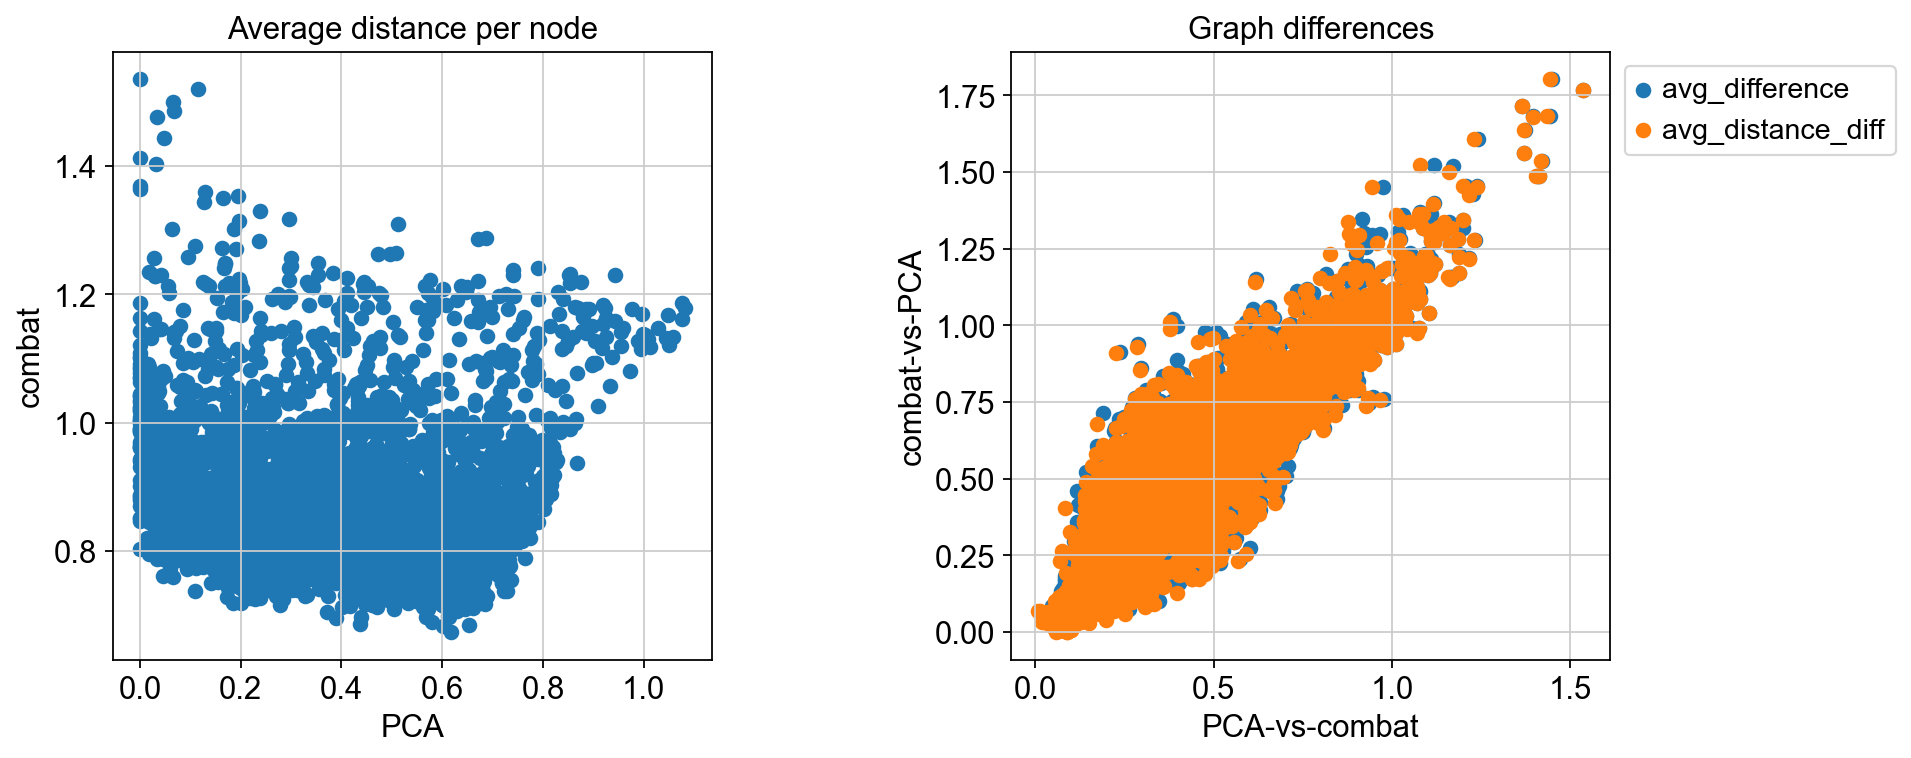

In [12]:
# Primary direction: neighborhoods defined by pca_key
atl.metrics.plot_distances_scatter(adata, pca_key, combat_key)

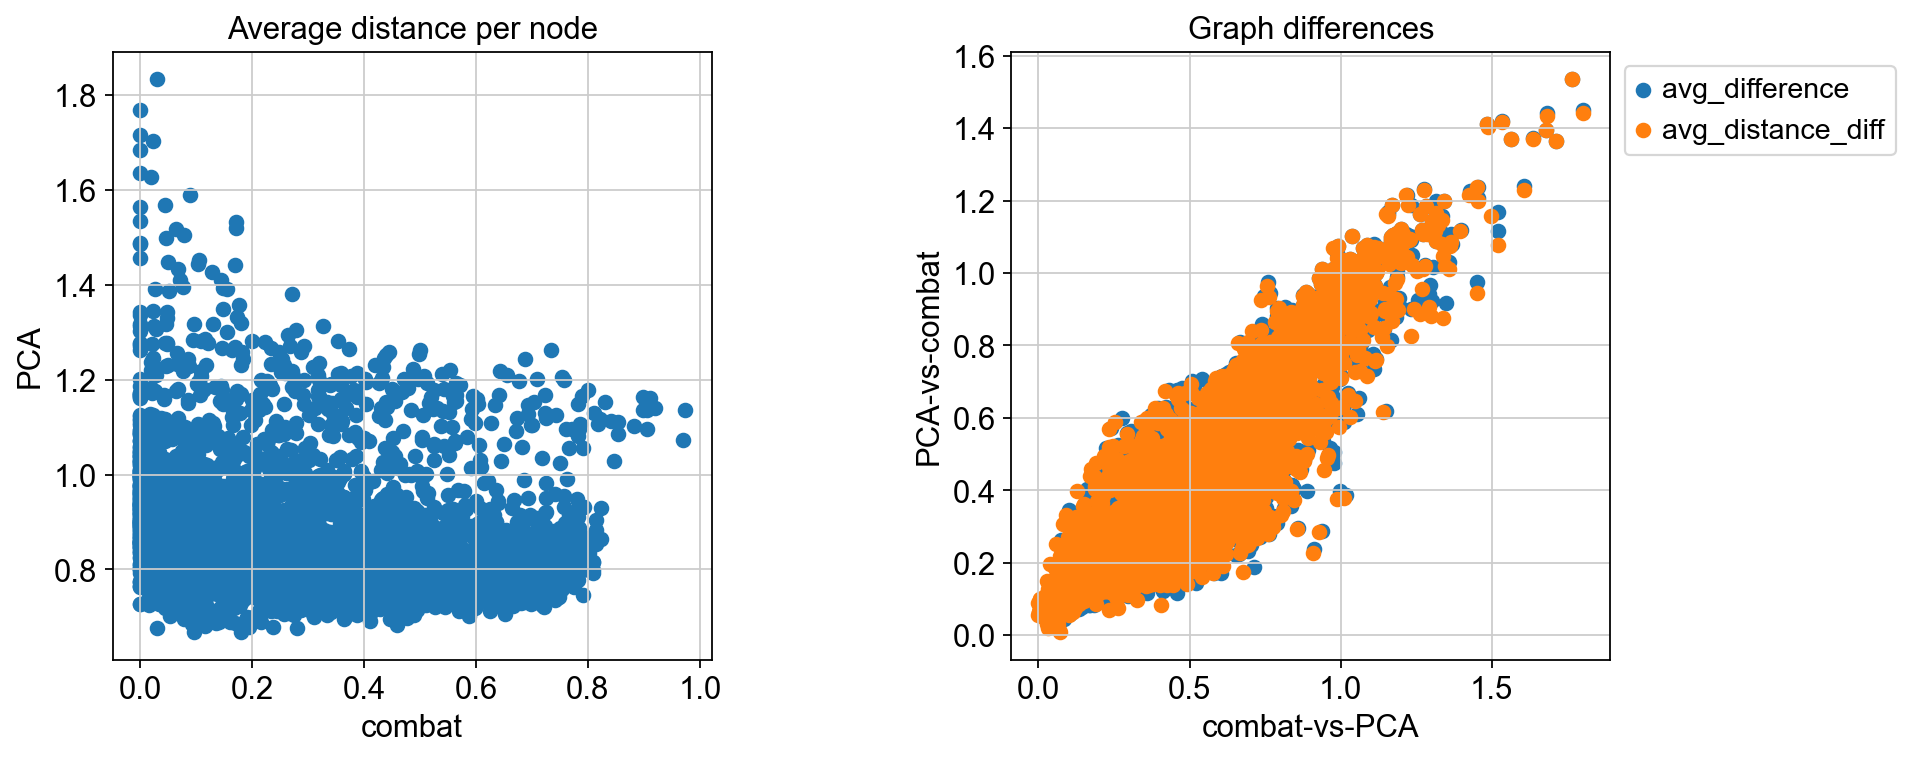

In [13]:
# Reverse direction: neighborhoods defined by combat_key
atl.metrics.plot_distances_scatter(adata, combat_key, pca_key)

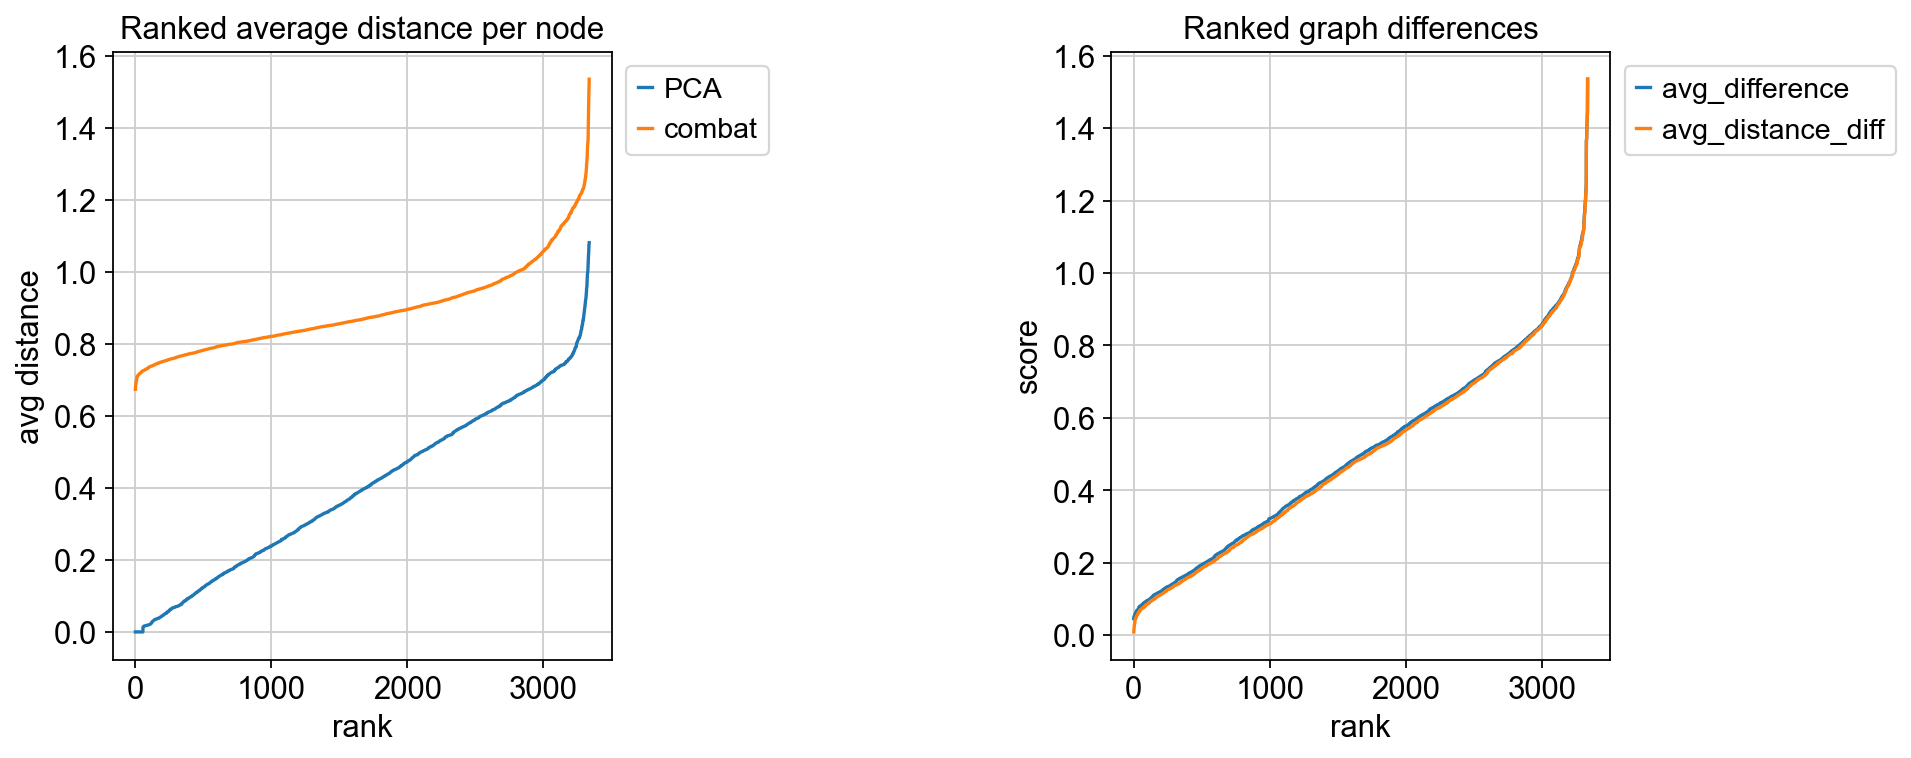

In [14]:
atl.metrics.plot_ranked_distances(adata, pca_key, combat_key)

## Step 4: Interpreting results and downstream use

After running the above, `adata.obs` contains per-cell dissimilarity scores you can use like any other cell-level annotation:

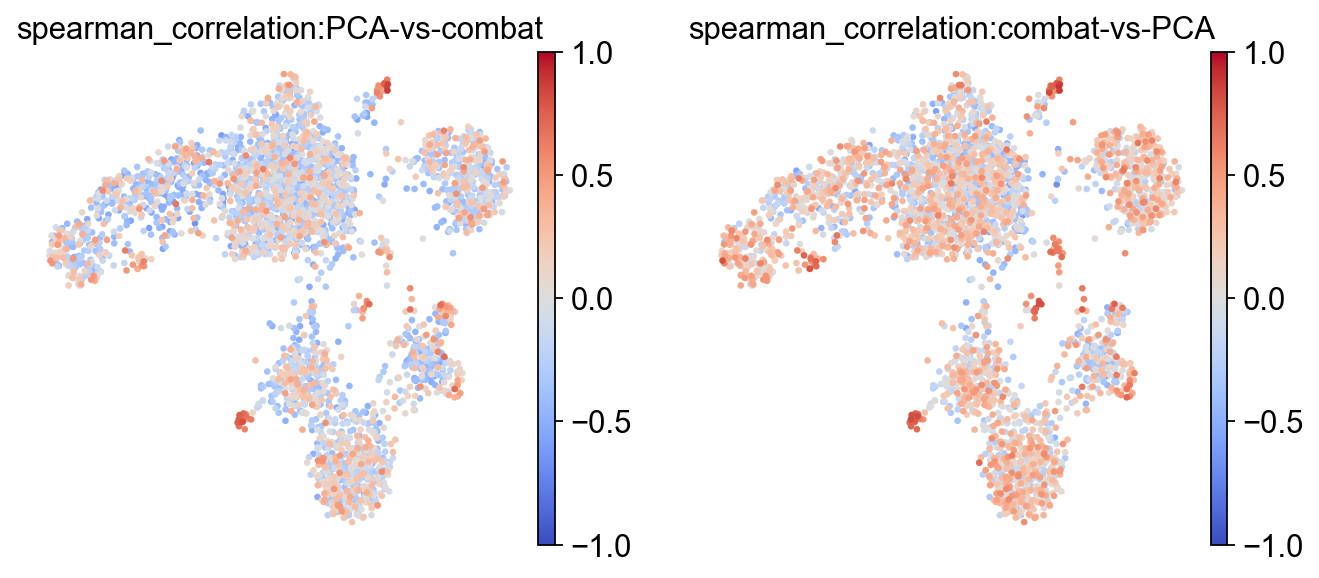

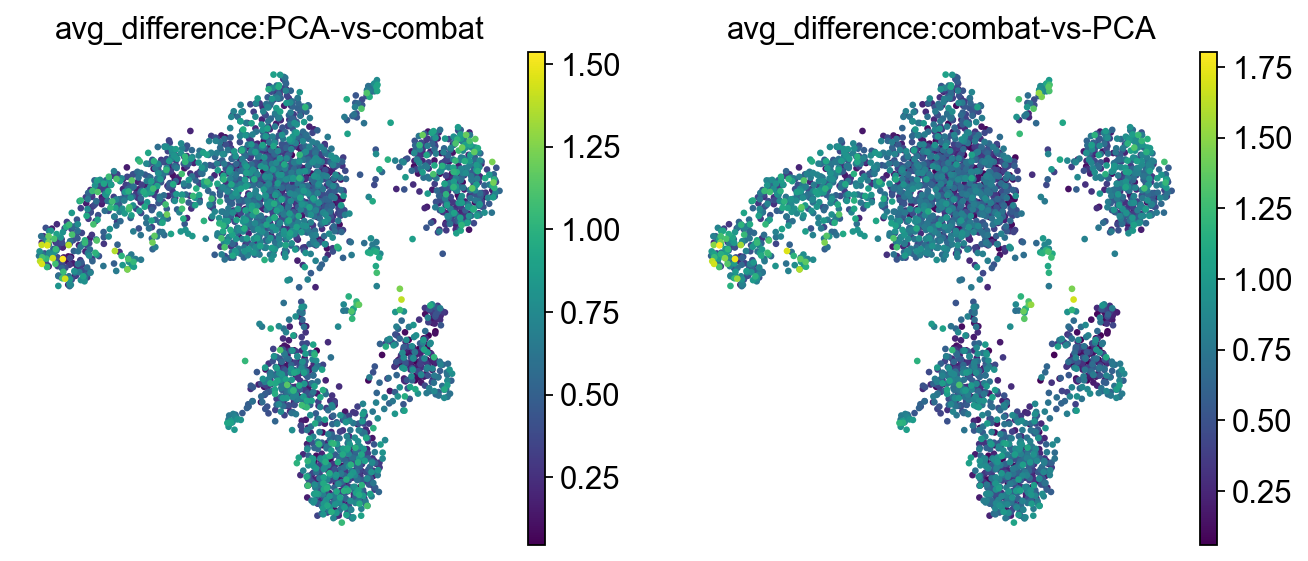

In [15]:
sc.pl.embedding(
    adata,
    basis=f"{pca_key}_umap",
    color=[
        f"spearman_correlation:{pca_key}-vs-{combat_key}",
        f"spearman_correlation:{combat_key}-vs-{pca_key}",
    ],
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

sc.pl.embedding(
    adata,
    basis=f"{pca_key}_umap",
    color=[
        f"avg_difference:{pca_key}-vs-{combat_key}",
        f"avg_difference:{combat_key}-vs-{pca_key}",
    ],
    cmap="viridis",
)

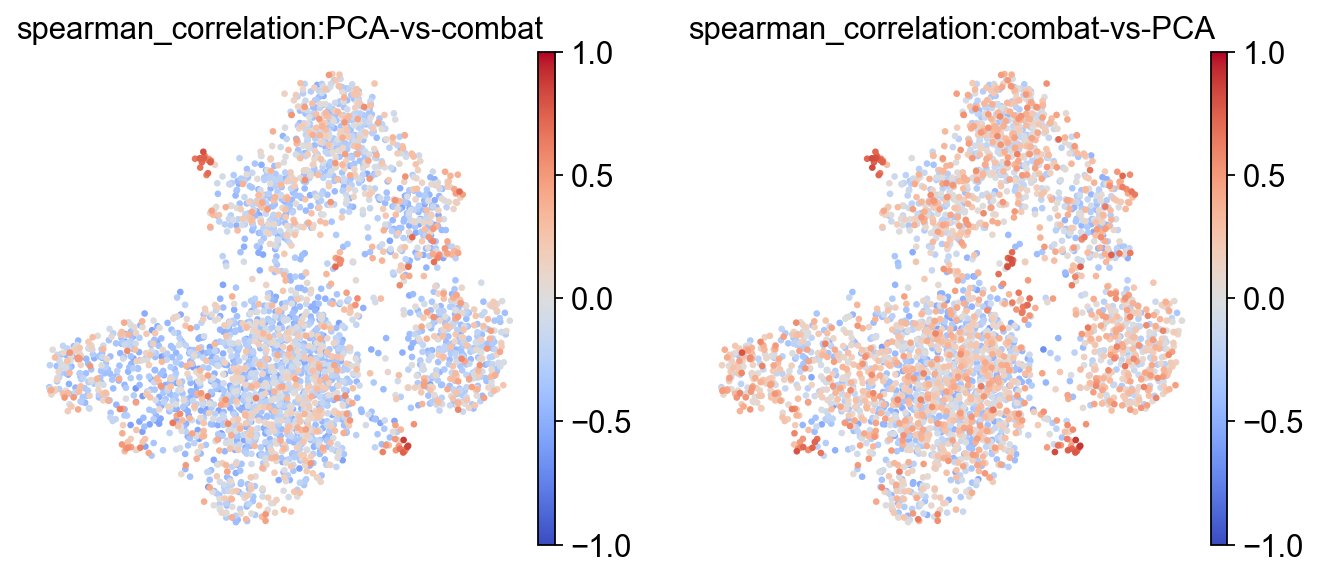

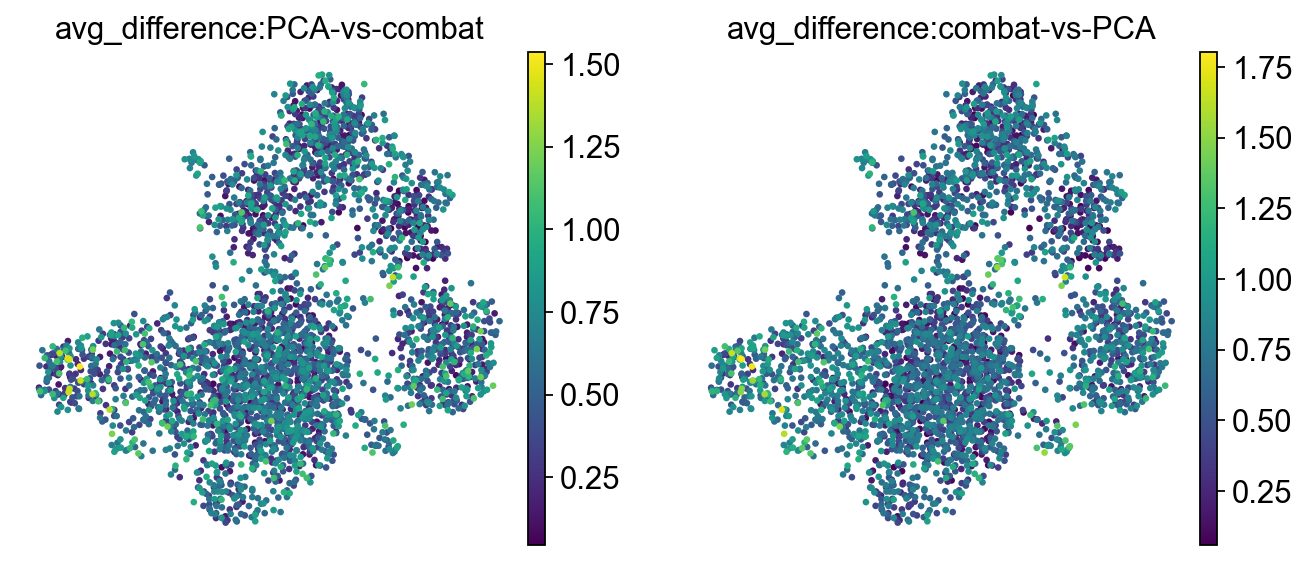

In [16]:
sc.pl.embedding(
    adata,
    basis=f"{combat_key}_umap",
    color=[
        f"spearman_correlation:{pca_key}-vs-{combat_key}",
        f"spearman_correlation:{combat_key}-vs-{pca_key}",
    ],
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

sc.pl.embedding(
    adata,
    basis=f"{combat_key}_umap",
    color=[
        f"avg_difference:{pca_key}-vs-{combat_key}",
        f"avg_difference:{combat_key}-vs-{pca_key}",
    ],
    cmap="viridis",
)

**What to look for:**

- **Low Spearman correlation** in a cluster → that cell population is organized very differently by the two methods. This could indicate a biologically meaningful population that one method handles better.
- **High `avg_difference`** combined with **low `avg_distance_1`** → tight neighborhood in embedding 1 that is spread out in embedding 2. The first method may be overcollapsing that population.
- **Symmetric disagreement** (high scores in both directions) → genuine structural difference in how the two methods embed those cells, not an artifact of which graph was used as reference.

## Notes on missing distances

Internally, `compare_distances` calls `compute_missing_distances` to fill in any pairwise distances that exist in the connectivity mask of integration 1 but are absent from the distance matrix of integration 2. This happens automatically and does not modify `adata` in place (the `inplace=False` default). The distances are computed from the raw embedding using Euclidean distance by default; pass `metric='cosine'` (or any `scipy.spatial.distance` metric) as a keyword argument if you need something different.